# Naive Bayes - Financial News Sentiment Analysis

**Algorithm:** Multinomial Naive Bayes  
**Dataset:** FinancialPhraseBank (4,845 headlines)  
**Task:** Classify financial news headlines as **Positive**, **Neutral**, or **Negative**

In [1]:
# Google Colab setup - mount Drive if in Colab
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/AI PROJECT DATASET/
    print('Running in Colab - Drive mounted')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style('whitegrid')
%matplotlib inline

In [3]:
df = pd.read_csv('all-data.csv', encoding='ISO-8859-1', header=None, names=['sentiment', 'headline'])
print(f'Shape: {df.shape}')
df.head()

Shape: (4846, 2)


,sentiment,headline
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4846 entries, 0 to 4845
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   sentiment  4846 non-null   str  
 1   headline   4846 non-null   str  
dtypes: str(2)
memory usage: 717.4 KB


In [5]:
# Check sentiment distribution
df['sentiment'].value_counts()

sentiment
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64

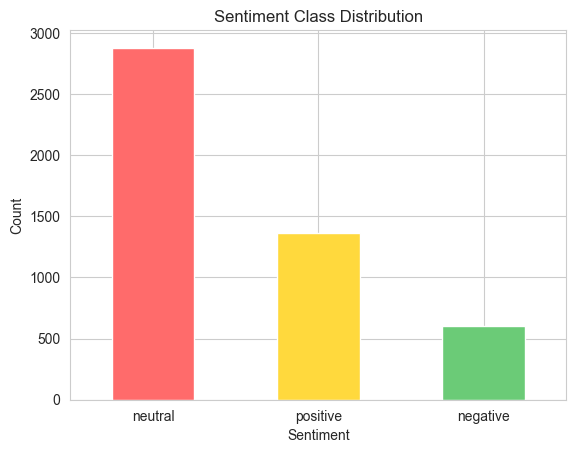

In [6]:
# Visualize sentiment distribution
colors = ['#ff6b6b', '#ffd93d', '#6bcb77']
df['sentiment'].value_counts().plot(kind='bar', color=colors)
plt.title('Sentiment Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [7]:
# Text preprocessing function with stopword removal
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def clean_text(text):
    text = text.lower()
    text = re.sub(f'[{string.punctuation}]', '', text)
    text = ' '.join(w for w in text.split() if w not in ENGLISH_STOP_WORDS)
    return re.sub(r'\s+', ' ', text).strip()

df['clean_headline'] = df['headline'].apply(clean_text)
df[['headline', 'clean_headline']].head()


,headline,clean_headline
0,"According to Gran , the company has no plans t...",according gran company plans production russia...
1,Technopolis plans to develop in stages an area...,technopolis plans develop stages area 100000 s...
2,The international electronic industry company ...,international electronic industry company elco...
3,With the new production plant the company woul...,new production plant company increase capacity...
4,According to the company 's updated strategy f...,according company s updated strategy years 200...


In [8]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_headline'], df['sentiment'], test_size=0.2, random_state=42, stratify=df['sentiment']
)
print(f'Train: {len(X_train)}, Test: {len(X_test)}')

Train: 3876, Test: 970


In [9]:
# Convert text to TF-IDF features
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
print(f'Feature matrix shape: {X_train_vec.shape}')

Feature matrix shape: (3876, 5000)


In [10]:
# Train Multinomial Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_vec, y_train)
y_pred = nb.predict(X_test_vec)

In [11]:
# Evaluation
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'\nClassification Report:\n{classification_report(y_test, y_pred)}')

Accuracy: 0.7072

Classification Report:
              precision    recall  f1-score   support

    negative       0.82      0.22      0.35       121
     neutral       0.71      0.96      0.81       576
    positive       0.68      0.39      0.50       273

    accuracy                           0.71       970
   macro avg       0.73      0.52      0.55       970
weighted avg       0.71      0.71      0.67       970



In [12]:
# Top predictive words per sentiment class
feature_names = vectorizer.get_feature_names_out()
for i, class_label in enumerate(nb.classes_):
    top10 = np.argsort(nb.feature_log_prob_[i])[-10:]
    words = [feature_names[j] for j in top10]
    print(f'{class_label.upper()}: {words}')


NEGATIVE: ['2009', 'net', 'year', 'period', 'decreased', 'sales', 'operating', 'profit', 'mn', 'eur']
NEUTRAL: ['shares', 'finnish', 'group', 'eur', 'said', 'new', 'million', 'business', 'finland', 'company']
POSITIVE: ['period', 'million', 'year', 'net', 'company', 'said', 'profit', 'sales', 'mn', 'eur']


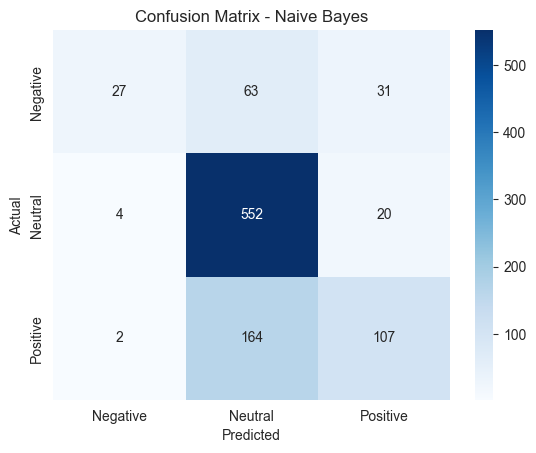

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['negative', 'neutral', 'positive'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.title('Confusion Matrix - Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [14]:
# Test with custom headlines + probability confidence
test_headlines = [
    "Company reports record profits this quarter",
    "Stock market crashes amid economic uncertainty",
    "Bank announces quarterly results in line with expectations"
]

test_clean = [clean_text(h) for h in test_headlines]
test_vec = vectorizer.transform(test_clean)
predictions = nb.predict(test_vec)
probs = nb.predict_proba(test_vec)

for h, p, prob in zip(test_headlines, predictions, probs):
    confidence = max(prob)
    print(f'{p.upper():>8} ({confidence:.0%} confident) | {h}')


POSITIVE (47% confident) | Company reports record profits this quarter
 NEUTRAL (79% confident) | Stock market crashes amid economic uncertainty
 NEUTRAL (66% confident) | Bank announces quarterly results in line with expectations


### Conclusion
Multinomial Naive Bayes classifies financial news sentiment effectively. It works well because words in positive/negative news have distinct probability distributions, which is exactly what Naive Bayes captures.